In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import HuberRegressor
from sklearn.model_selection import cross_val_score

from pygam import LinearGAM, s
from functools import reduce
import operator

from xgboost import XGBRegressor

# For ANN
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ---------- Configuration ----------
RANDOM_STATE = 42
TEST_SIZE = 0.2          # last 20% of time as final test set
CV_FOLDS = 5

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

In [2]:
# ======================================================
# 1) Load data and prepare spatio-temporal information
# ======================================================
df = pd.read_csv("/Users/arup/Documents/ug_thesis/data_normalized.csv")
# expected columns: ['time', 'latitude', 'longitude', 'kd', 'chl']

FEATURES = ['kd']
TARGET = 'chl'

# --- parse time, drop missing, sort by time ---
df['time'] = pd.to_datetime(df['time'], errors='coerce')
df = df.dropna(subset=['time', 'latitude', 'longitude'] + FEATURES + [TARGET])
df = df.sort_values('time').reset_index(drop=True)

# ---------- Time-based train/test split ----------
n_samples = len(df)
test_size_int = max(1, int(np.floor(TEST_SIZE * n_samples)))
test_start_idx = n_samples - test_size_int

train_idx = np.arange(0, test_start_idx)
test_idx = np.arange(test_start_idx, n_samples)

df_train = df.iloc[train_idx].reset_index(drop=True)
df_test  = df.iloc[test_idx].reset_index(drop=True)

X_train = df_train[FEATURES].values
y_train = df_train[TARGET].values

X_test  = df_test[FEATURES].values
y_test  = df_test[TARGET].values

df_coords_train = df_train[['time', 'latitude', 'longitude']].copy()

In [3]:
# ======================================================
# 2) Spatio-Temporal Blocked CV splitter
# ======================================================
class SpatioTemporalBlockSplit:
    """
    Spatio-temporal cross-validator.

    - Works on data already sorted by time.
    - Uses forward-chaining over time (no future -> past leakage).
    - Adds simple spatial blocking using latitude/longitude bins.
    - For each fold:
        * Train = earlier time indices, excluding chosen spatial test blocks
        * Test  = later time window AND chosen spatial blocks
    Compatible with scikit-learn's CV API (split, get_n_splits).
    """

    def __init__(
        self,
        df_coords,
        n_splits=5,
        time_col='time',
        lat_col='latitude',
        lon_col='longitude',
        n_lat_blocks=4,
        n_lon_blocks=4,
        random_state=42
    ):
        self.df_coords = df_coords.reset_index(drop=True)
        self.n_splits = n_splits
        self.time_col = time_col
        self.lat_col = lat_col
        self.lon_col = lon_col
        self.n_lat_blocks = n_lat_blocks
        self.n_lon_blocks = n_lon_blocks
        self.random_state = random_state

        self.df_coords[self.time_col] = pd.to_datetime(
            self.df_coords[self.time_col], errors='coerce'
        )

        self._compute_blocks()

    def _compute_blocks(self):
        lat = self.df_coords[self.lat_col].values
        lon = self.df_coords[self.lon_col].values

        lat_min, lat_max = lat.min(), lat.max()
        lon_min, lon_max = lon.min(), lon.max()

        lat_edges = np.linspace(lat_min, lat_max, self.n_lat_blocks + 1)
        lon_edges = np.linspace(lon_min, lon_max, self.n_lon_blocks + 1)

        lat_bin = np.digitize(lat, lat_edges) - 1
        lon_bin = np.digitize(lon, lon_edges) - 1

        lat_bin = np.clip(lat_bin, 0, self.n_lat_blocks - 1)
        lon_bin = np.clip(lon_bin, 0, self.n_lon_blocks - 1)

        self.block_ids = lat_bin * self.n_lon_blocks + lon_bin

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

    def split(self, X=None, y=None, groups=None):
        n_samples = len(self.df_coords)
        indices = np.arange(n_samples)
        rng = np.random.RandomState(self.random_state)

        # Split the training time range into (n_splits + 1) segments
        for k in range(1, self.n_splits + 1):
            test_start = int(n_samples * k / (self.n_splits + 1))
            test_end = int(n_samples * (k + 1) / (self.n_splits + 1)) if k < self.n_splits else n_samples

            test_time_idx = indices[test_start:test_end]
            train_time_idx = indices[:test_start]

            test_blocks_unique = np.unique(self.block_ids[test_time_idx])

            if len(test_blocks_unique) > 1:
                n_test_blocks = max(1, len(test_blocks_unique) // 2)
                test_blocks = rng.choice(test_blocks_unique, size=n_test_blocks, replace=False)
            else:
                test_blocks = test_blocks_unique

            is_test_block = np.isin(self.block_ids, test_blocks)

            test_mask = np.zeros_like(indices, dtype=bool)
            test_mask[test_time_idx] = True
            test_indices = indices[test_mask & is_test_block]

            train_mask = np.zeros_like(indices, dtype=bool)
            train_mask[train_time_idx] = True
            train_mask &= ~np.isin(self.block_ids, test_blocks)
            train_indices = indices[train_mask]

            if len(train_indices) == 0 or len(test_indices) == 0:
                continue

            yield train_indices, test_indices

cv_st = SpatioTemporalBlockSplit(
    df_coords=df_coords_train,
    n_splits=CV_FOLDS,
    time_col='time',
    lat_col='latitude',
    lon_col='longitude',
    n_lat_blocks=4,
    n_lon_blocks=4,
    random_state=RANDOM_STATE
)

In [4]:
# ======================================================
# 3) Helper functions
# ======================================================
def print_metrics(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name:20s} | R2 = {r2:.4f} | RMSE = {rmse:.4f}")
    return r2, rmse

def cv_r2_score(model, X, y, cv, is_gam=False, scaler=None):
    """
    Return mean and std of CV R2 using provided CV splitter.
    Works for sklearn-like models and pygam (is_gam=True).
    """
    scores = []
    for train_idx, val_idx in cv.split(X):
        Xtr, Xval = X[train_idx], X[val_idx]
        ytr, yval = y[train_idx], y[val_idx]

        if scaler is not None:
            scaler_fold = StandardScaler()
            Xtr = scaler_fold.fit_transform(Xtr)
            Xval = scaler_fold.transform(Xval)

        if is_gam:
            gam = model()
            gam.fit(Xtr, ytr)
            pred = gam.predict(Xval)
        else:
            m = model if hasattr(model, "fit") and not hasattr(model, "get_params") else model
            m = model.__class__(**model.get_params()) if hasattr(model, "get_params") else model
            m.fit(Xtr, ytr)
            pred = m.predict(Xval)

        scores.append(r2_score(yval, pred))

    scores = np.array(scores)
    return scores.mean(), scores.std()

In [5]:
# ======================================================
# 4) GAM
# ======================================================
n_terms = len(FEATURES)
terms = reduce(operator.add, (s(i) for i in range(n_terms)))

gam = LinearGAM(terms).fit(X_train, y_train)
y_pred_gam = gam.predict(X_test)
print_metrics("GAM (test)", y_test, y_pred_gam)

gam_cv_mean, gam_cv_std = cv_r2_score(
    lambda: LinearGAM(terms),
    X_train, y_train,
    cv=cv_st,
    is_gam=True
)
print(f"GAM CV R2 (spatio-temporal): {gam_cv_mean:.4f} ± {gam_cv_std:.4f}")

GAM (test)           | R2 = 0.9364 | RMSE = 0.9869
GAM CV R2 (spatio-temporal): 0.9409 ± 0.0598


In [6]:
# ======================================================
# 5) Random Forest
# ======================================================
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print_metrics("RandomForest (test)", y_test, y_pred_rf)

rf_cv_mean = cross_val_score(
    rf,
    X_train, y_train,
    cv=cv_st,
    scoring='r2',
    n_jobs=-1
).mean()
print(f"RandomForest CV R2 (spatio-temporal): {rf_cv_mean:.4f}")

RandomForest (test)  | R2 = 0.9328 | RMSE = 1.0149
RandomForest CV R2 (spatio-temporal): 0.9402


In [5]:
# ======================================================
# 6) XGBoost
# ======================================================
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
y_pred_xgb = xgb.predict(X_test)
print_metrics("XGBoost (test)", y_test, y_pred_xgb)

xgb_cv_mean = cross_val_score(
    xgb,
    X_train, y_train,
    cv=cv_st,
    scoring='r2',
    n_jobs=-1
).mean()
print(f"XGBoost CV R2 (spatio-temporal): {xgb_cv_mean:.4f}")

XGBoost (test)       | R2 = 0.9343 | RMSE = 1.0036
XGBoost CV R2 (spatio-temporal): 0.9380


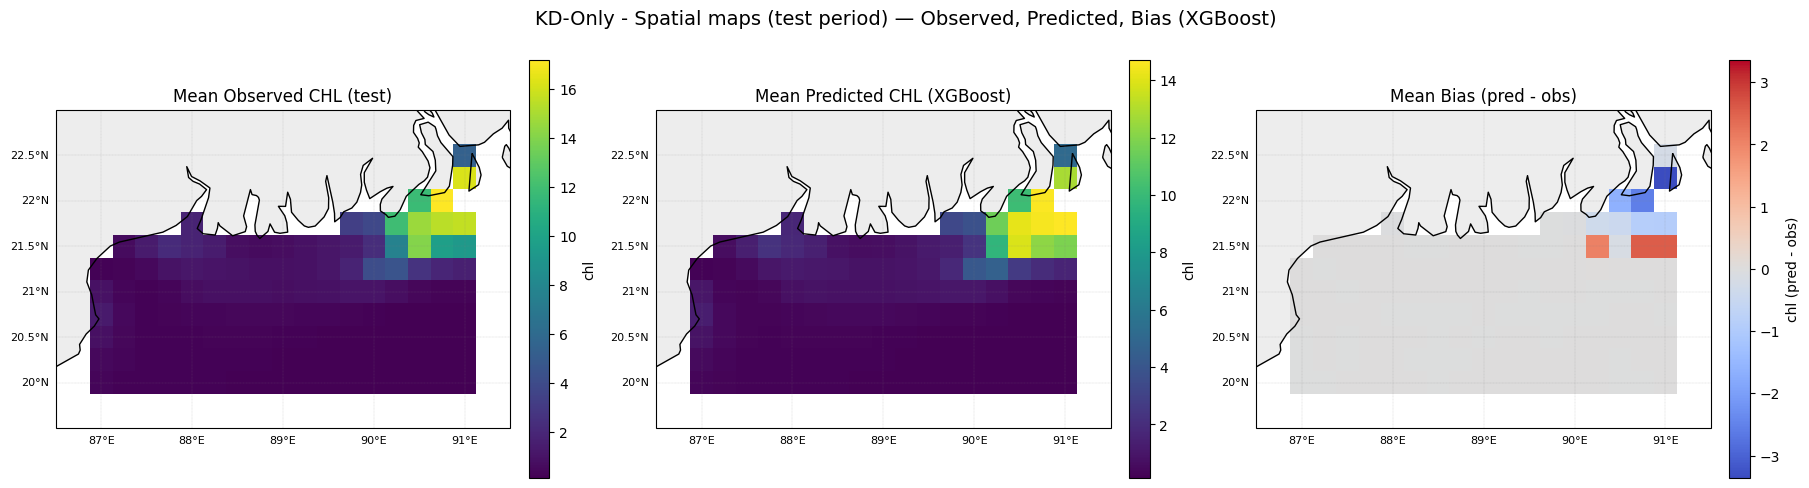

In [6]:
# ------------------ Cartopy three-panel spatial maps ------------------
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import TwoSlopeNorm

# ---------------- config ----------------
min_samples = 3            # mask cells with fewer than this many test samples
bias_cmap = 'coolwarm'
obs_cmap = 'viridis'
save_fig = True
outpath = "figures/spatial_xgb_bias_cartopy.png"
dpi = 300
# ----------------------------------------

# Ensure df_test has predictions (if not, compute)
if 'pred_xgb' not in df_test.columns:
    df_test = df_test.copy()
    df_test['pred_xgb'] = xgb.predict(df_test[FEATURES].values)
df_test['bias_xgb'] = df_test['pred_xgb'] - df_test[TARGET]

# Aggregate to grid (mean obs, mean pred, mean bias, count)
grouped = df_test.groupby(['latitude','longitude']).agg(
    obs_mean = (TARGET, 'mean'),
    pred_mean = ('pred_xgb', 'mean'),
    bias_mean = ('bias_xgb', 'mean'),
    count = (TARGET, 'count')
).reset_index()

# sorted unique coordinates
lats = np.sort(grouped['latitude'].unique())
lons = np.sort(grouped['longitude'].unique())

# create 2D grids
Lon, Lat = np.meshgrid(lons, lats)   # shape (nlat, nlon)

# pivot arrays to match grid indices
obs_grid  = grouped.pivot(index='latitude', columns='longitude', values='obs_mean').reindex(index=lats, columns=lons).values
pred_grid = grouped.pivot(index='latitude', columns='longitude', values='pred_mean').reindex(index=lats, columns=lons).values
bias_grid = grouped.pivot(index='latitude', columns='longitude', values='bias_mean').reindex(index=lats, columns=lons).values
count_grid= grouped.pivot(index='latitude', columns='longitude', values='count').reindex(index=lats, columns=lons).fillna(0).values

# mask low-sample cells
mask = count_grid < min_samples
obs_grid_mask  = np.ma.masked_where(mask, obs_grid)
pred_grid_mask = np.ma.masked_where(mask, pred_grid)
bias_grid_mask = np.ma.masked_where(mask, bias_grid)

# Choose symmetric norm for bias
bias_vmax = np.nanmax(np.abs(bias_grid_mask))
bias_norm = TwoSlopeNorm(vcenter=0.0, vmin=-bias_vmax, vmax=bias_vmax)

# Prepare figure with PlateCarree projection
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(18,5), constrained_layout=True)

# common extent with a small margin
lon_min, lon_max = float(lons.min())-0.5, float(lons.max())+0.5
lat_min, lat_max = float(lats.min())-0.5, float(lats.max())+0.5
extent = [lon_min, lon_max, lat_min, lat_max]

# --- Observed ---
ax0 = fig.add_subplot(1,3,1, projection=proj)
ax0.set_extent(extent, crs=proj)
pcm0 = ax0.pcolormesh(Lon, Lat, obs_grid_mask, transform=proj, cmap=obs_cmap, shading='auto')
ax0.add_feature(cfeature.COASTLINE.with_scale('50m'))
ax0.add_feature(cfeature.LAND.with_scale('50m'), facecolor='lightgray', alpha=0.4)
ax0.set_title("Mean Observed CHL (test)")
cbar0 = fig.colorbar(pcm0, ax=ax0, orientation='vertical', fraction=0.046, pad=0.04)
cbar0.set_label('chl')

# --- Predicted ---
ax1 = fig.add_subplot(1,3,2, projection=proj)
ax1.set_extent(extent, crs=proj)
pcm1 = ax1.pcolormesh(Lon, Lat, pred_grid_mask, transform=proj, cmap=obs_cmap, shading='auto')
ax1.add_feature(cfeature.COASTLINE.with_scale('50m'))
ax1.add_feature(cfeature.LAND.with_scale('50m'), facecolor='lightgray', alpha=0.4)
ax1.set_title("Mean Predicted CHL (XGBoost)")
cbar1 = fig.colorbar(pcm1, ax=ax1, orientation='vertical', fraction=0.046, pad=0.04)
cbar1.set_label('chl')

# --- Bias (pred - obs) ---
ax2 = fig.add_subplot(1,3,3, projection=proj)
ax2.set_extent(extent, crs=proj)
pcm2 = ax2.pcolormesh(Lon, Lat, bias_grid_mask, transform=proj, cmap=bias_cmap, shading='auto', norm=bias_norm)
ax2.add_feature(cfeature.COASTLINE.with_scale('50m'))
ax2.add_feature(cfeature.LAND.with_scale('50m'), facecolor='lightgray', alpha=0.4)
ax2.set_title("Mean Bias (pred - obs)")
cbar2 = fig.colorbar(pcm2, ax=ax2, orientation='vertical', fraction=0.046, pad=0.04)
cbar2.set_label('chl (pred - obs)')

# Add gridlines and labels
for ax in [ax0, ax1, ax2]:
    gl = ax.gridlines(draw_labels=True, linewidth=0.2, color='gray', alpha=0.6, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size':8}
    gl.ylabel_style = {'size':8}

plt.suptitle("KD-Only - Spatial maps (test period) — Observed, Predicted, Bias (XGBoost)", fontsize=14)
plt.show()

In [8]:
# ======================================================
# 7) Robust Linear Regression (Huber)
# ======================================================
scaler_lr = StandardScaler()
X_train_scaled = scaler_lr.fit_transform(X_train)
X_test_scaled = scaler_lr.transform(X_test)

huber = HuberRegressor(epsilon=1.35, max_iter=1000)
huber.fit(X_train_scaled, y_train)
y_pred_huber = huber.predict(X_test_scaled)
print_metrics("Huber RobustLR (test)", y_test, y_pred_huber)

huber_pipe = make_pipeline(StandardScaler(), HuberRegressor(epsilon=1.35, max_iter=1000))
huber_cv_mean = cross_val_score(
    huber_pipe,
    X_train, y_train,
    cv=cv_st,
    scoring='r2',
    n_jobs=-1
).mean()
print(f"Huber CV R2 (spatio-temporal): {huber_cv_mean:.4f}")

Huber RobustLR (test) | R2 = 0.6058 | RMSE = 2.4577
Huber CV R2 (spatio-temporal): 0.6394


Epoch 1/200
254/254 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 1.7944 - mse: 1.7944 - val_loss: 0.4227 - val_mse: 0.4227
Epoch 2/200
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.8651 - mse: 0.8651 - val_loss: 0.4175 - val_mse: 0.4175
Epoch 3/200
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7100 - mse: 0.7100 - val_loss: 0.4139 - val_mse: 0.4139
Epoch 4/200
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6432 - mse: 0.6432 - val_loss: 0.4173 - val_mse: 0.4173
Epoch 5/200
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6063 - mse: 0.6063 - val_loss: 0.4226 - val_mse: 0.4226
Epoch 6/200
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5987 - mse: 0.5987 - val_loss: 0.4721 - val_mse: 0.4721
Epoch 7/200
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5591 - mse: 0.5591 - val_loss: 0.5007 - val_mse: 0.5007
Epoch 8/200
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5617 - mse: 0.5617 - val_loss: 0.5450 - val_mse: 0.5450
Epoch 9/200
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/

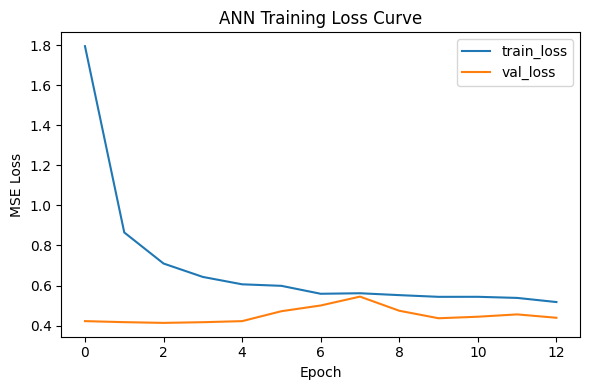

In [9]:
# ======================================================
# 8) ANN (Keras)
# ======================================================
scaler_ann = StandardScaler()
X_train_ann = scaler_ann.fit_transform(X_train)
X_test_ann = scaler_ann.transform(X_test)

def build_ann(input_dim):
    model = Sequential([
        Dense(64, activation='relu', input_shape=(input_dim,)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.1),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mse'])
    return model

ann = build_ann(X_train_ann.shape[1])
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

history = ann.fit(
    X_train_ann, y_train,
    validation_split=0.15,
    epochs=200,
    batch_size=256,
    callbacks=[es],
    verbose=1
)

y_pred_ann = ann.predict(X_test_ann).ravel()
print_metrics("ANN (test)", y_test, y_pred_ann)

def ann_cv_r2(X, y, cv):
    scores = []
    for train_idx, val_idx in cv.split(X):
        Xtr, Xv = X[train_idx], X[val_idx]
        ytr, yv = y[train_idx], y[val_idx]

        sc = StandardScaler()
        Xtr_s = sc.fit_transform(Xtr)
        Xv_s = sc.transform(Xv)

        m = build_ann(Xtr_s.shape[1])
        m.fit(
            Xtr_s, ytr,
            epochs=100,
            batch_size=256,
            validation_split=0.1,
            callbacks=[EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)],
            verbose=0
        )
        pred = m.predict(Xv_s).ravel()
        scores.append(r2_score(yv, pred))

    scores = np.array(scores)
    return scores.mean(), scores.std()

ann_cv_mean, ann_cv_std = ann_cv_r2(X_train, y_train, cv=cv_st)
print(f"ANN CV R2 (spatio-temporal, {CV_FOLDS}-fold): {ann_cv_mean:.4f} ± {ann_cv_std:.4f}")

# ---------- Plot ANN loss curve ----------
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('ANN Training Loss Curve')
plt.legend()
plt.tight_layout()
plt.show()


Model summary (CV R2, Test R2):
GAM          | CV R2 = 0.9409 | Test R2 = 0.9364
RandomForest | CV R2 = 0.9402 | Test R2 = 0.9328
XGBoost      | CV R2 = 0.9380 | Test R2 = 0.9343
Huber        | CV R2 = 0.6394 | Test R2 = 0.6058
ANN          | CV R2 = 0.9259 | Test R2 = 0.9174


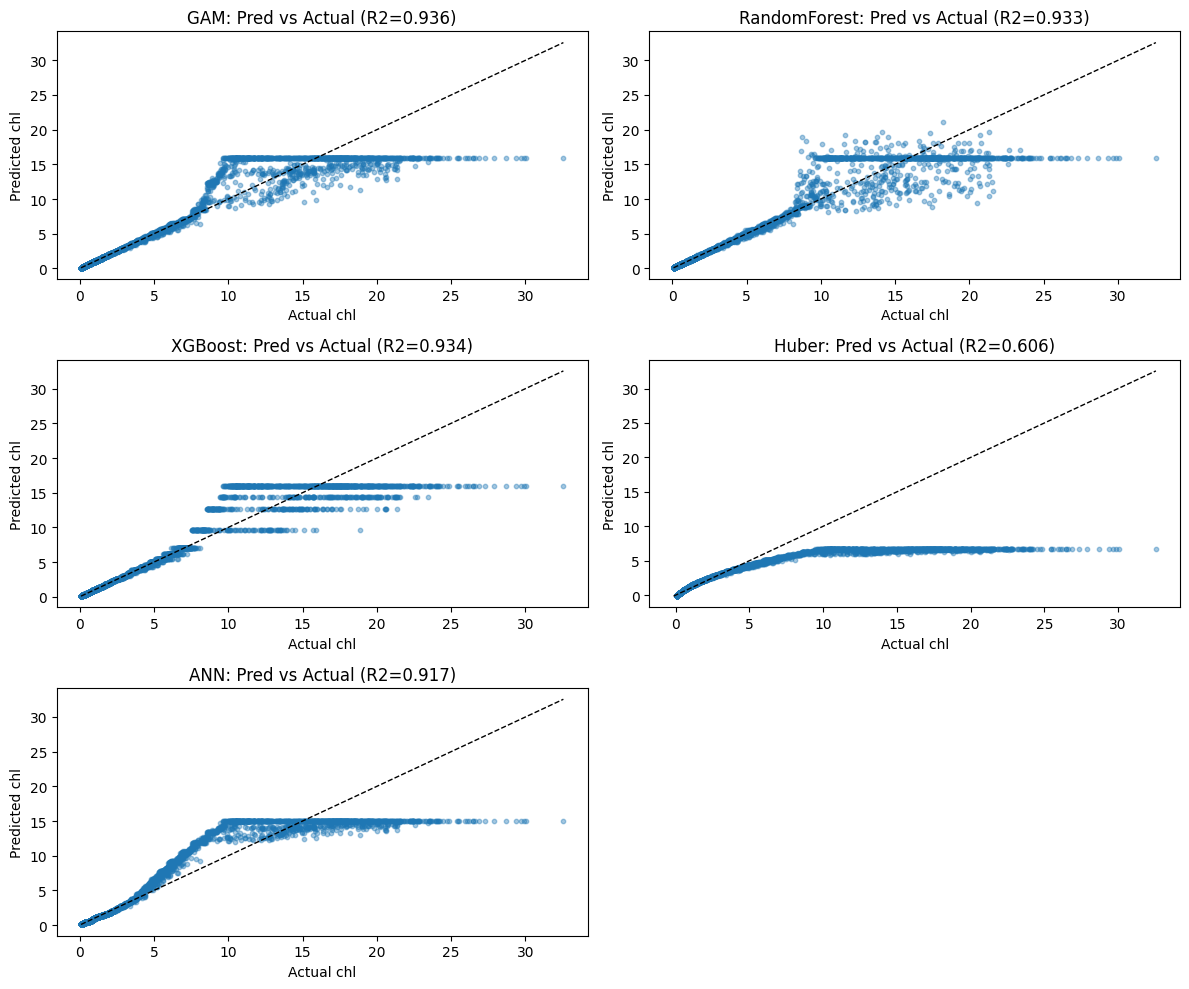

In [10]:
# ======================================================
# 9) Summary and Predicted vs Actual plots
# ======================================================
models_info = [
    ("GAM",          gam_cv_mean,   r2_score(y_test, y_pred_gam)),
    ("RandomForest", rf_cv_mean,    r2_score(y_test, y_pred_rf)),
    ("XGBoost",      xgb_cv_mean,   r2_score(y_test, y_pred_xgb)),
    ("Huber",        huber_cv_mean, r2_score(y_test, y_pred_huber)),
    ("ANN",          ann_cv_mean,   r2_score(y_test, y_pred_ann)),
]

print("\nModel summary (CV R2, Test R2):")
for name, cv_r2, test_r2 in models_info:
    print(f"{name:12s} | CV R2 = {cv_r2:.4f} | Test R2 = {test_r2:.4f}")

# Predicted vs actual
plt.figure(figsize=(12, 10))
model_preds = {
    'GAM':          y_pred_gam,
    'RandomForest': y_pred_rf,
    'XGBoost':      y_pred_xgb,
    'Huber':        y_pred_huber,
    'ANN':          y_pred_ann
}

i = 1
for name, preds in model_preds.items():
    plt.subplot(3, 2, i)
    plt.scatter(y_test, preds, s=10, alpha=0.4)
    mn = min(y_test.min(), preds.min())
    mx = max(y_test.max(), preds.max())
    plt.plot([mn, mx], [mn, mx], 'k--', linewidth=1)
    plt.xlabel("Actual chl")
    plt.ylabel("Predicted chl")
    plt.title(f"{name}: Pred vs Actual (R2={r2_score(y_test, preds):.3f})")
    i += 1

plt.tight_layout()
plt.show()

In [11]:
# # ======================================================
# # Create models/ folder and save all models inside it
# # ======================================================

# import os
# import joblib
# import pickle  # optional, if you prefer pickle for some models

# # Create folder if not exists
# os.makedirs("models", exist_ok=True)

# # ---------- 1) Random Forest ----------
# joblib.dump(rf, "models/rf_model.joblib")
# print("Saved: models/rf_model.joblib")

# # ---------- 2) XGBoost ----------
# joblib.dump(xgb, "models/xgb_model.joblib")
# print("Saved: models/xgb_model.joblib")

# # ---------- 3) GAM (pyGAM) ----------
# # Your pyGAM version has no .save(), so use joblib (or pickle)
# joblib.dump(gam, "models/gam_model.joblib")
# print("Saved: models/gam_model.joblib")

# # ---------- 4) ANN (Keras) ----------
# ann.save("models/ann_model.keras")
# print("Saved: models/ann_model.keras")
